In [1]:
import pandas as pd
import numpy as np

caminho = "datasets/raw/MQTT/"
print("A carregar e a rotular os dados...")

# Tráfego Normal
df_normal = pd.read_csv(caminho + "biflow_normal.csv")
df_normal['Label_Binario'] = 0
df_normal['Classe'] = 'Normal'

# Tráfego Malicioso
df_bruteforce = pd.read_csv(caminho + "biflow_mqtt_bruteforce.csv")
df_bruteforce['Label_Binario'] = 1
df_bruteforce['Classe'] = 'Bruteforce_MQTT'

df_scan_A = pd.read_csv(caminho + "biflow_scan_A.csv")
df_scan_A['Label_Binario'] = 1
df_scan_A['Classe'] = 'Scan_A'

df_scan_sU = pd.read_csv(caminho + "biflow_scan_sU.csv")
df_scan_sU['Label_Binario'] = 1
df_scan_sU['Classe'] = 'Scan_UDP'

df_sparta = pd.read_csv(caminho + "biflow_sparta.csv")
df_sparta['Label_Binario'] = 1
df_sparta['Classe'] = 'Sparta_Composto'

# Consolidar
dataset = pd.concat([df_normal, df_bruteforce, df_scan_A, df_scan_sU, df_sparta], ignore_index=True)
print(f"Dataset consolidado: {dataset.shape[0]} pacotes.")

A carregar e a rotular os dados...
Dataset consolidado: 259379 pacotes.


In [2]:
print("A verificar a integridade matemática dos dados...")

# Substituir infinitos por NaN e limpar
dataset = dataset.replace([np.inf, -np.inf], np.nan)
valores_corrompidos = dataset.isnull().sum().sum()

if valores_corrompidos > 0:
    dataset_limpo = dataset.dropna()
    print(f"Limpeza feita! Apagámos {valores_corrompidos} erros.")
else:
    dataset_limpo = dataset
    print("✅ O dataset está perfeitamente limpo.")

A verificar a integridade matemática dos dados...
✅ O dataset está perfeitamente limpo.


In [3]:
from sklearn.model_selection import train_test_split

print("A preparar os dados de Treino e Teste...")

# Remover as respostas e os identificadores que "viciam" a IA
colunas_a_remover = ['ip_src', 'ip_dst', 'prt_src', 'prt_dst', 'proto', 'is_attack', 'Label_Binario', 'Classe']

X = dataset_limpo.drop(columns=colunas_a_remover)
y = dataset_limpo['Classe']

# Divisão 80/20 com proporção mantida (stratify)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"O modelo vai estudar com {X_train.shape[0]} pacotes e ser testado com {X_test.shape[0]}.")

A preparar os dados de Treino e Teste...
O modelo vai estudar com 207503 pacotes e ser testado com 51876.


In [4]:
import joblib
import os

def guardar_componente_ia(objeto, nome_ficheiro):
    """
    Guarda qualquer modelo ou scaler na pasta 'modelos_treinados'.
    """
    pasta = 'modelos_treinados'
    os.makedirs(pasta, exist_ok=True)
    
    caminho = os.path.join(pasta, f"{nome_ficheiro}.joblib")
    joblib.dump(objeto, caminho)
    print(f"✅ Sucesso: '{nome_ficheiro}' guardado em {caminho}")

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import time

print("A normalizar e a treinar o modelo base (Baseline)...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

inicio = time.time()
modelo_rf.fit(X_train_scaled, y_train)
fim = time.time()

previsoes = modelo_rf.predict(X_test_scaled)
print(f"Treino base (100 árvores) concluído em {round(fim - inicio, 2)} segundos!")
print(f"Precisão Base: {accuracy_score(y_test, previsoes) * 100:.2f}%")

guardar_componente_ia(modelo_rf, "random_forest_mqtt")
guardar_componente_ia(scaler, "scaler_mqtt")

A normalizar e a treinar o modelo base (Baseline)...
Treino base (100 árvores) concluído em 5.14 segundos!
Precisão Base: 77.22%
✅ Sucesso: 'random_forest_mqtt' guardado em modelos_treinados/random_forest_mqtt.joblib
✅ Sucesso: 'scaler_mqtt' guardado em modelos_treinados/scaler_mqtt.joblib


A desenhar o cérebro da Inteligência Artificial...


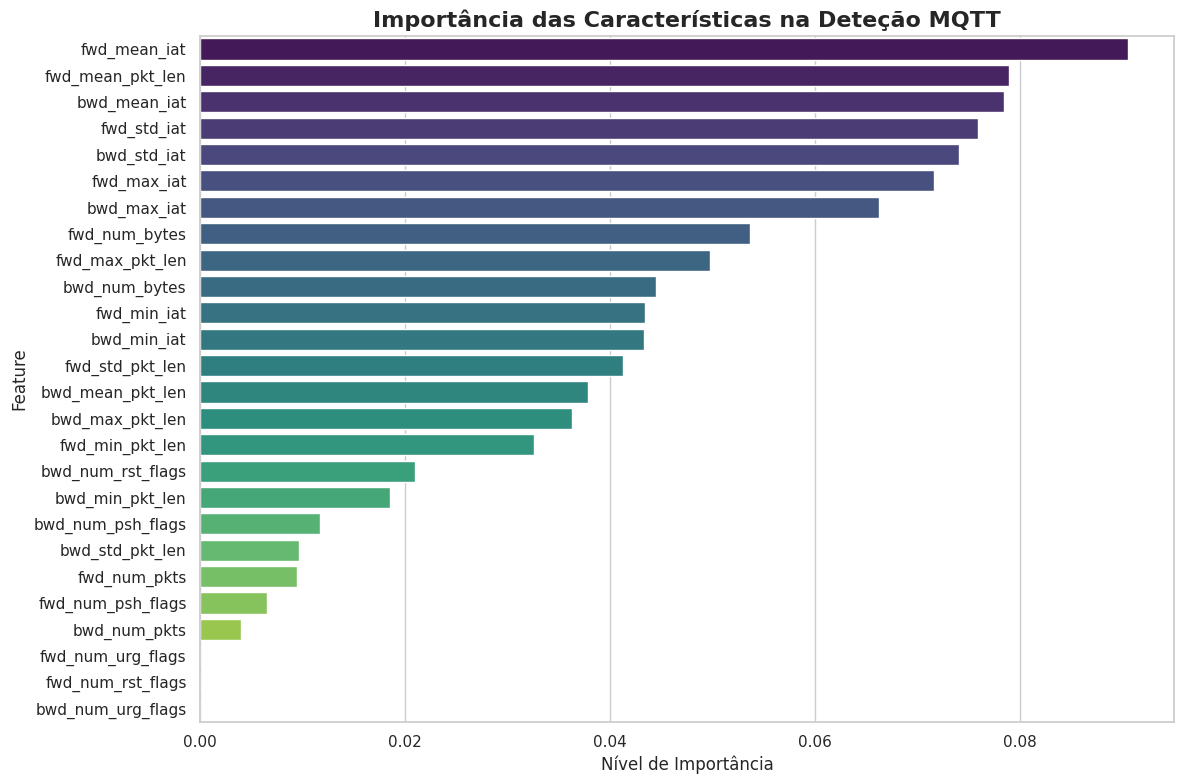

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

print("A desenhar o cérebro da Inteligência Artificial...")

importancias = modelo_rf.feature_importances_
df_importancias = pd.DataFrame({'Caracteristica': X.columns, 'Importancia': importancias})
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

sns.barplot(x='Importancia', y='Caracteristica', data=df_importancias, hue='Caracteristica', legend=False, palette='viridis')

plt.title('Importância das Características na Deteção MQTT', fontsize=16, fontweight='bold')
plt.xlabel('Nível de Importância', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
print("A treinar o modelo VIP (Eficiência Máxima - Apenas 15 Features)...")

top_15_features = df_importancias.head(15)['Caracteristica'].tolist()

X_train_vip = X_train[top_15_features]
X_test_vip = X_test[top_15_features]

scaler_vip = StandardScaler()
X_train_scaled_vip = scaler_vip.fit_transform(X_train_vip)
X_test_scaled_vip = scaler_vip.transform(X_test_vip)

# O Modelo Otimizado
modelo_rf_vip = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
modelo_rf_vip.fit(X_train_scaled_vip, y_train)

previsoes_vip = modelo_rf_vip.predict(X_test_scaled_vip)
print(f"Precisão do Modelo VIP: {accuracy_score(y_test, previsoes_vip) * 100:.2f}%")
print(classification_report(y_test, previsoes_vip))

guardar_componente_ia(modelo_rf_vip, "random_forest_mqtt_vip")
guardar_componente_ia(scaler_vip, "scaler_mqtt_vip")

print("Modelo treinado e guardado com sucesso!")

A treinar o modelo VIP (Eficiência Máxima - Apenas 15 Features)...
Precisão do Modelo VIP: 77.29%
                 precision    recall  f1-score   support

Bruteforce_MQTT       0.99      0.95      0.97      3339
         Normal       0.68      0.78      0.73     17202
         Scan_A       0.99      0.78      0.87      5138
       Scan_UDP       0.85      0.68      0.76      7933
Sparta_Composto       0.75      0.77      0.76     18264

       accuracy                           0.77     51876
      macro avg       0.85      0.79      0.82     51876
   weighted avg       0.78      0.77      0.78     51876

✅ Sucesso: 'random_forest_mqtt_vip' guardado em modelos_treinados/random_forest_mqtt_vip.joblib
✅ Sucesso: 'scaler_mqtt_vip' guardado em modelos_treinados/scaler_mqtt_vip.joblib
Modelo treinado e guardado com sucesso!


In [8]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

print("A iniciar procura de hiperparâmetros (Versão Leve)...")

# 1. Definir a grelha de parâmetros (O que faltava no erro)
parametros_grelha = {
    'n_estimators': [100, 200],          
    'max_depth': [None, 20, 30],         
    'min_samples_split': [2, 5],         
    'criterion': ['gini', 'entropy'],    
    'class_weight': ['balanced', None]   
}

# 2. Criar a amostra reduzida para evitar que o Kernel trave
X_amostra, _, y_amostra, _ = train_test_split(
    X_train_scaled_vip, y_train, train_size=0.05, stratify=y_train, random_state=42
)

# 3. Configurar a Procura Aleatória
procura_aleatoria = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=parametros_grelha,
    n_iter=5,      # Testa 5 combinações aleatórias
    cv=2,          # Validação cruzada de 2 dobras
    random_state=42,
    n_jobs=1       # Usa apenas 1 núcleo para garantir estabilidade
)

# 4. Executar
procura_aleatoria.fit(X_amostra, y_amostra)

print(f"✅ Concluído! Melhores parâmetros encontrados: \n{procura_aleatoria.best_params_}")

A iniciar procura de hiperparâmetros (Versão Leve)...
✅ Concluído! Melhores parâmetros encontrados: 
{'n_estimators': 200, 'min_samples_split': 5, 'max_depth': None, 'criterion': 'gini', 'class_weight': None}


In [9]:
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, accuracy_score
import sys
sys.path.append("./results")
from features_ml import FEATURES_ML
import time



print("A preparar o Isolation Forest com RobustScaler...")

# 1. Seleção de Features para Isolation (Não supervisionado)
# Dica: Às vezes, as features que o RF ignora são as que o IF adora.
# Vamos usar as TOP 15 do RF, mas podes experimentar aumentar para 20 se o recall continuar baixo.
features_isolation = ['fwd_num_pkts', 'fwd_num_psh_flags', 'fwd_mean_iat', 'fwd_num_bytes', 'bwd_num_bytes']

X_train_if = X_train[features_isolation]
X_test_if = X_test[features_isolation]

# Para treinar usando as features escolhidas pelo dataset_analyser 
# (ainda precisa de melhorias, grau de acerto muito baixo)
#X_train_if = X_train[FEATURES_ML]
#X_test_if = X_test[FEATURES_ML]

# 2. Aplicar RobustScaler (Mais resistente a ataques no treino)
scaler_robust = RobustScaler()
X_train_robust = scaler_robust.fit_transform(X_train_if)
X_test_robust = scaler_robust.transform(X_test_if)

# 3. Filtrar apenas Normais para o treino (Semi-supervisionado)
X_train_normal_robust = X_train_robust[y_train == 'Normal']

# 4. Configurar o Modelo
# Aumentamos n_estimators para 300 e contamination para 0.05 para ser mais sensível
modelo_if_robust = IsolationForest(n_estimators=300, contamination=0.05, max_samples='auto', random_state=42, n_jobs=-1)

print("A treinar com RobustScaler (Apenas dados normais)...")
inicio = time.time()
modelo_if_robust.fit(X_train_normal_robust)
fim = time.time()

# 5. Previsão e Avaliação
previsoes_raw = modelo_if_robust.predict(X_test_robust)
y_test_binario = y_test.apply(lambda x: 0 if x == 'Normal' else 1)
previsoes_if = [1 if x == -1 else 0 for x in previsoes_raw]

print(f"Treino concluído em {round(fim - inicio, 2)} segundos!")
print(f"Precisão Global: {accuracy_score(y_test_binario, previsoes_if) * 100:.2f}%")
print("\nRelatório de Classificação:")
print(classification_report(y_test_binario, previsoes_if, target_names=['Normal', 'Anomalia']))

# Guardar o novo scaler e modelo
guardar_componente_ia(scaler_robust, "scaler_robust_if")
guardar_componente_ia(modelo_if_robust, "isolation_forest_robust_MQTT")

A preparar o Isolation Forest com RobustScaler...
A treinar com RobustScaler (Apenas dados normais)...
Treino concluído em 1.18 segundos!
Precisão Global: 61.05%

Relatório de Classificação:
              precision    recall  f1-score   support

      Normal       0.46      0.95      0.62     17202
    Anomalia       0.95      0.44      0.60     34674

    accuracy                           0.61     51876
   macro avg       0.70      0.70      0.61     51876
weighted avg       0.79      0.61      0.61     51876

✅ Sucesso: 'scaler_robust_if' guardado em modelos_treinados/scaler_robust_if.joblib
✅ Sucesso: 'isolation_forest_robust_MQTT' guardado em modelos_treinados/isolation_forest_robust_MQTT.joblib


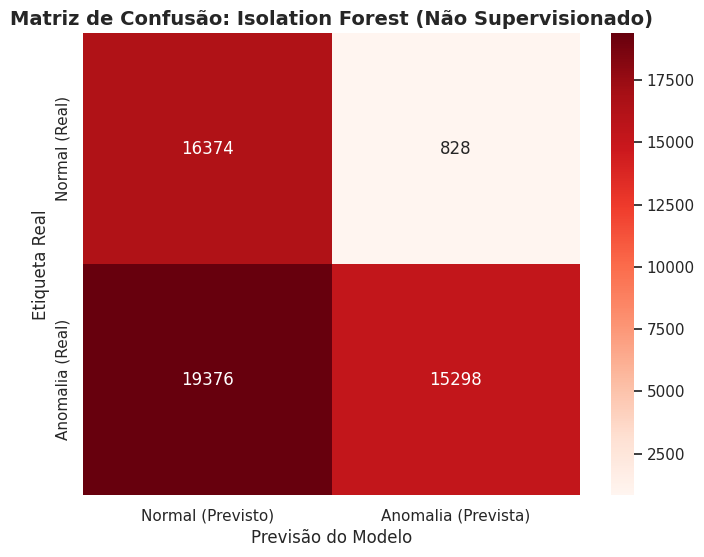

--- Análise de Fiabilidade ---
Falsos Positivos (Alarmes Falsos): 828
Falsos Negativos (Ataques Não Detetados): 19376
Taxa de Deteção (Recall): 44.12%


In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Gerar a Matriz de Confusão
conf_matrix_if = confusion_matrix(y_test_binario, previsoes_if)

# 2. Configurar o gráfico
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_if, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Normal (Previsto)', 'Anomalia (Prevista)'],
            yticklabels=['Normal (Real)', 'Anomalia (Real)'])

plt.title('Matriz de Confusão: Isolation Forest (Não Supervisionado)', fontsize=14, fontweight='bold')
plt.ylabel('Etiqueta Real')
plt.xlabel('Previsão do Modelo')
plt.show()

# 3. Cálculo de métricas de fiabilidade
tn, fp, fn, tp = conf_matrix_if.ravel()
print(f"--- Análise de Fiabilidade ---")
print(f"Falsos Positivos (Alarmes Falsos): {fp}")
print(f"Falsos Negativos (Ataques Não Detetados): {fn}")
print(f"Taxa de Deteção (Recall): {round(tp/(tp+fn)*100, 2)}%")